[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_9_4_Exercise.ipynb)

# Classification Metrics from Scratch: Breast Cancer Diagnosis

**About this notebook.** The capstones in `18_1_9_1` through `18_1_9_3` walk through the *full* classification pipeline on messy real-world data. This exercise focuses on one thing: **understanding exactly what precision, recall, F1, and AUC mean** — by computing them from scratch before relying on sklearn.

**Dataset:** `sklearn.datasets.load_breast_cancer()` — 569 tumours, 30 numeric features, binary target (malignant = 1, benign = 0). No cleaning needed.

**Three parts:**

| Part | Skill |
|------|-------|
| 1 | Fit a classifier; build the confusion matrix from raw predictions |
| 2 | Compute precision, recall, and F1 *without* `sklearn.metrics` |
| 3 | Tune the decision threshold and plot the precision–recall tradeoff |

Cells marked **`# YOUR TURN`** need you to fill in the blank. **Execute to see solution** cells reveal the answers.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import sklearn.metrics as skm

sns.set_style('whitegrid')

data = load_breast_cancer()
X = data['data']
y = data['target']    # 1 = malignant, 0 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Fit a logistic regression pipeline (scaling is important for LR)
clf = Pipeline([('scaler', StandardScaler()),
                ('lr',     LogisticRegression(max_iter=1000, random_state=42))])
clf.fit(X_train, y_train)

y_pred  = clf.predict(X_test)           # hard predictions (0 or 1)
y_proba = clf.predict_proba(X_test)[:, 1]  # P(malignant)

print(f'Test accuracy: {(y_pred == y_test).mean():.4f}')
print(f'Positive class (malignant) fraction in test set: {y_test.mean():.3f}')

Test accuracy: 0.9860
Positive class (malignant) fraction in test set: 0.629


---
## Part 1 — Confusion Matrix from Scratch

A confusion matrix counts the four possible outcomes for each prediction:

| | Predicted Positive (1) | Predicted Negative (0) |
|---|---|---|
| **Actual Positive (1)** | True Positive (TP) | False Negative (FN) |
| **Actual Negative (0)** | False Positive (FP) | True Negative (TN) |

**YOUR TURN:** Use boolean arrays — no loops needed.

* `TP` = predictions where `y_pred == 1` and `y_test == 1`
* `FP` = predictions where `y_pred == 1` and `y_test == 0`
* `FN` = predictions where `y_pred == 0` and `y_test == 1`
* `TN` = predictions where `y_pred == 0` and `y_test == 0`

In [2]:
# Uncomment the lines below and replace each ___ with your code.
#
# YOUR TURN — Part 1
# TP = ___
# FP = ___
# FN = ___
# TN = ___

# print(f'TP={TP}  FP={FP}  FN={FN}  TN={TN}')
# print(f'Total: {TP + FP + FN + TN}  (should equal {len(y_test)})')

# print('\nsklearn cross-check:')
# print(skm.confusion_matrix(y_test, y_pred))

In [3]:
# @title Execute to see solution
print("""
TP = ((y_pred == 1) & (y_test == 1)).sum()
FP = ((y_pred == 1) & (y_test == 0)).sum()
FN = ((y_pred == 0) & (y_test == 1)).sum()
TN = ((y_pred == 0) & (y_test == 0)).sum()
""")
TP = int(((y_pred == 1) & (y_test == 1)).sum())
FP = int(((y_pred == 1) & (y_test == 0)).sum())
FN = int(((y_pred == 0) & (y_test == 1)).sum())
TN = int(((y_pred == 0) & (y_test == 0)).sum())
print(f'TP={TP}  FP={FP}  FN={FN}  TN={TN}')
print(f'Total: {TP + FP + FN + TN}  (should equal {len(y_test)})')
print('sklearn cross-check:')
print(skm.confusion_matrix(y_test, y_pred))


TP = ((y_pred == 1) & (y_test == 1)).sum()
FP = ((y_pred == 1) & (y_test == 0)).sum()
FN = ((y_pred == 0) & (y_test == 1)).sum()
TN = ((y_pred == 0) & (y_test == 0)).sum()

TP=89  FP=1  FN=1  TN=52
Total: 143  (should equal 143)
sklearn cross-check:
[[52  1]
 [ 1 89]]


---
## Part 2 — Precision, Recall, and F1 from Scratch

Three metrics that matter more than accuracy when classes are imbalanced or the costs of FP and FN differ:

| Metric | Formula | Plain English |
|--------|---------|---------------|
| **Precision** | TP / (TP + FP) | Of all tumours we flagged as malignant, how many actually were? |
| **Recall** | TP / (TP + FN) | Of all actually malignant tumours, how many did we catch? |
| **F1** | 2 · Precision · Recall / (Precision + Recall) | Harmonic mean — penalises extreme imbalance between the two |

**YOUR TURN:** Compute each metric using only `TP`, `FP`, `FN`, `TN`.

In [4]:
# Uncomment the lines below and replace each ___ with your code.
#
# YOUR TURN — Part 2
# precision = ___
# recall    = ___
# f1        = ___

# print(f'Precision: {precision:.4f}')
# print(f'Recall:    {recall:.4f}')
# print(f'F1:        {f1:.4f}')

# print('\nsklearn cross-check:')
# print(skm.classification_report(y_test, y_pred, target_names=['benign','malignant']))

In [5]:
# @title Execute to see solution
print("""
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * precision * recall / (precision + recall)
""")
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * precision * recall / (precision + recall)
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1:        {f1:.4f}')
print('\nsklearn cross-check:')
print(skm.classification_report(y_test, y_pred, target_names=['benign','malignant']))


precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * precision * recall / (precision + recall)

Precision: 0.9889
Recall:    0.9889
F1:        0.9889

sklearn cross-check:
              precision    recall  f1-score   support

      benign       0.98      0.98      0.98        53
   malignant       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



**Reflection 2.** In cancer diagnosis, a false negative (missed malignant tumour) is far worse than a false positive (unnecessary follow-up). Which metric — precision or recall — should you prioritise for this use case? How would you change the decision threshold to improve that metric?

*Your answer:*

---
## Part 3 — Threshold Tuning

By default, sklearn predicts class 1 when `P(malignant) >= 0.5`. Lowering the threshold catches more malignant cases (higher recall) at the cost of more false alarms (lower precision).

**YOUR TURN:** Loop over thresholds 0.1–0.9, compute precision and recall at each, and find the threshold that maximises F1.

In [6]:
# Uncomment the lines below and replace each ___ with your code.
#
# YOUR TURN — Part 3
# thresholds = np.arange(0.10, 0.95, 0.05)
# precisions = []
# recalls    = []
# f1s        = []

# for t in thresholds:
#     y_pred_t = (y_proba >= ___).astype(int)  # YOUR TURN: compare y_proba to threshold t
#     tp = int(((y_pred_t == 1) & (y_test == 1)).sum())
#     fp = int(((y_pred_t == 1) & (y_test == 0)).sum())
#     fn = int(((y_pred_t == 0) & (y_test == 1)).sum())
#     p = tp / (tp + fp) if (tp + fp) > 0 else 0
#     r = tp / (tp + fn) if (tp + fn) > 0 else 0
#     f = 2 * p * r / (p + r) if (p + r) > 0 else 0
#     precisions.append(p)
#     recalls.append(r)
#     f1s.append(f)

# best_idx       = ___        # YOUR TURN: index of maximum F1
# best_threshold = thresholds[best_idx]
# print(f'Best threshold: {best_threshold:.2f}  →  Precision={precisions[best_idx]:.3f}  Recall={recalls[best_idx]:.3f}  F1={f1s[best_idx]:.3f}')

In [7]:
# @title Execute to see solution
print("""
y_pred_t = (y_proba >= t).astype(int)

best_idx = np.argmax(f1s)
""")
thresholds2 = np.arange(0.10, 0.95, 0.05)
precisions2, recalls2, f1s2 = [], [], []
for t in thresholds2:
    y_pred_t = (y_proba >= t).astype(int)
    tp = int(((y_pred_t == 1) & (y_test == 1)).sum())
    fp = int(((y_pred_t == 1) & (y_test == 0)).sum())
    fn = int(((y_pred_t == 0) & (y_test == 1)).sum())
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    precisions2.append(p); recalls2.append(r); f1s2.append(f)
best_idx2 = int(np.argmax(f1s2))
best_threshold = thresholds2[best_idx2]
print(f'Best threshold: {best_threshold:.2f}  →  Precision={precisions2[best_idx2]:.3f}  Recall={recalls2[best_idx2]:.3f}  F1={f1s2[best_idx2]:.3f}')
thresholds = thresholds2; precisions = precisions2; recalls = recalls2; f1s = f1s2; best_idx = best_idx2


y_pred_t = (y_proba >= t).astype(int)

best_idx = np.argmax(f1s)

Best threshold: 0.40  →  Precision=0.989  Recall=0.989  F1=0.989


### 3b. Visualise the precision–recall tradeoff

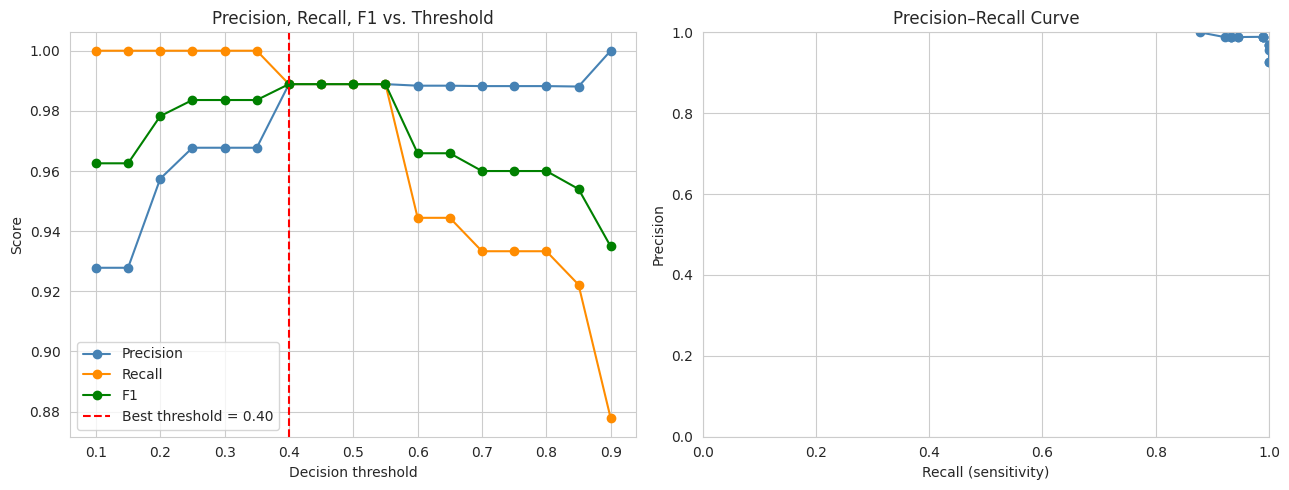

In [8]:
# Given — plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(thresholds, precisions, marker='o', label='Precision', color='steelblue')
axes[0].plot(thresholds, recalls,    marker='o', label='Recall',    color='darkorange')
axes[0].plot(thresholds, f1s,        marker='o', label='F1',        color='green')
axes[0].axvline(best_threshold, color='red', linestyle='--', linewidth=1.5,
                label=f'Best threshold = {best_threshold:.2f}')
axes[0].set_xlabel('Decision threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision, Recall, F1 vs. Threshold')
axes[0].legend()

axes[1].plot(recalls, precisions, marker='o', color='steelblue')
axes[1].set_xlabel('Recall (sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall Curve')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

**Reflection 3.** Look at what happens to precision and recall as you lower the threshold below 0.5.

1. Which metric goes up and which goes down? Why does this trade-off happen mechanically (in terms of TP, FP, FN)?
2. For this breast cancer use case, would you use the default threshold (0.5) or the best-F1 threshold you found? Justify your choice.

*Your answers:*

---
## Next Steps

This exercise closes out the **Classification Basics** module (Notebooks 1–6 plus the capstones in `18_1_9_1`–`18_1_9_3`). The next module moves from tree-based classifiers to **logistic regression** — a linear model that predicts class probabilities directly.

<a href="../18_2_LogisticRegression/18_2_1_LogReg_Intro_w_Titanic.ipynb">Continue to: Logistic Regression →</a>